<div style="display: inline-block; padding:20px; border-radius:10px; background-color:#1a5276; 
color:white; vertical-align: middle; text-align: center; font-size: 40px; width: 95%">
    <h4>🔍 Намерение покупателей совершать покупки онлайн</h4>
    <h6 style="padding: 10px">Преподаватель: Елена Кантонистова Кандидат физико-математических наук, выпускница школы анализа данных Яндекса (ШАД)</h6>
</div>

 **Разведочный анализ данных:** **https://stepik.org/course/177213**

### Описание данных:

* **Значение параметров Administrative, Administrative_Duration, Informational, Informational_Duration, ProductRelated, ProductRelated_Duration - ("Административная", "Административная продолжительность", "Информационная", "Информационная продолжительность", "Связанная с продуктом" и "Связанная с продуктом продолжительность")** - представляют количество различных типов страниц, посещенных посетителем в течение данного сеанса, и общее время, проведенное на каждой из этих категорий страниц. Значения этих полей выводятся из информации об URL-адресах посещаемых пользователем страниц и обновляются в режиме реального времени, когда пользователь выполняет какое-либо действие, например, переходит с одной страницы на другую. 
* **Значение параметров BounceRates, ExitRates и PageValues ("Показатель отказов", "Показатель посещаемости" и "Ценность страницы")** - представляют собой показатели, измеряемые "Google Analytics" для каждой страницы сайта электронной коммерции. 
* **Значение параметра BounceRates ("Показатель отказов")** - для веб-страницы относится к проценту посетителей, которые заходят на сайт с этой страницы, а затем покидают его ("показатель отказов"), не вызывая никаких других запросов к серверу аналитики в течение этого сеанса. 
* **Значение параметра ExitRates ("Показатель отказов")** - для конкретной веб-страницы рассчитывается как процент всех просмотров страницы, которые были последними в сеансе. 
* **Значение параметра PageValues ("Ценность-Значение страницы")** - представляет собой среднее значение для веб-страницы, которую пользователь посетил перед завершением транзакции электронной коммерции. 
* **Значение параметра SpecialDay ("Особый день")** -  указывает на близость времени посещения сайта к определенному особому дню (например, Дню матери, Дню Святого Валентина), в который сеансы с большей вероятностью завершатся транзакцией. Значение этого параметра определяется с учетом динамики электронной коммерции, такой как промежуток времени между датой заказа и датой доставки. Например, для дня Святого Валентина это значение принимает ненулевое значение в период со 2 по 12 февраля, нулевое значение до и после этой даты, если только она не близка к другому особому дню, и его максимальное значение, равное 1, приходится на 8 февраля. 
* Набор данных также включает **OperatingSystems - операционную систему, Browser - браузер, Region - регион, TrafficType - тип трафика**, **VisitorType** - тип посетителя, возвращающегося или нового посетителя, логическое значение, указывающее, является ли дата посещения **Weekend** - выходным, и **Month** - месяц года. 
* **Revenue** - Доход

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

from IPython.display import display


import warnings
warnings.filterwarnings("ignore")

In [2]:
%matplotlib inline

pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",None)
pd.set_option("display.width", 500)

In [3]:
import os
import sys

sys.path.insert(0, os.path.dirname(os.getcwd()))


In [ ]:
from Datasets.DF import DATASET

try:
    df = pd.read_csv(DATASET)
    print(f"✅ Загружено успешно!")
except Exception as e:
    print(f"❌ Ошибка загрузки {DATASET}: {str(e)}")
    raise

**Наименование колонок**

In [ ]:
for i, col in enumerate(df.columns, 1):
    print(f"    {i:2d}. '{col}'")


Наименование колонок:
     1. 'Administrative'
     2. 'Administrative_Duration'
     3. 'Informational'
     4. 'Informational_Duration'
     5. 'ProductRelated'
     6. 'ProductRelated_Duration'
     7. 'BounceRates'
     8. 'ExitRates'
     9. 'PageValues'
    10. 'SpecialDay'
    11. 'Month'
    12. 'OperatingSystems'
    13. 'Browser'
    14. 'Region'
    15. 'TrafficType'
    16. 'VisitorType'
    17. 'Weekend'
    18. 'Revenue'


**Типы данных**

In [49]:
for i, col in enumerate(df.columns, 1):
    print(f"    {i:2d}. '{col}': {df[col].dtype}")

     1. 'Administrative': int64
     2. 'Administrative_Duration': float64
     3. 'Informational': int64
     4. 'Informational_Duration': float64
     5. 'ProductRelated': int64
     6. 'ProductRelated_Duration': float64
     7. 'BounceRates': float64
     8. 'ExitRates': float64
     9. 'PageValues': float64
    10. 'SpecialDay': float64
    11. 'Month': str
    12. 'OperatingSystems': int64
    13. 'Browser': int64
    14. 'Region': int64
    15. 'TrafficType': int64
    16. 'VisitorType': str
    17. 'Weekend': bool
    18. 'Revenue': bool


**Дублирующиеся строки**

In [6]:
print(f"Дублирующиеся строки: {df.duplicated().sum()}, что составляет {df.duplicated().sum() / df.shape[0] * 100:.2f}% от {df.shape[0]:,d} общего числа строк")


Дублирующиеся строки: 109, что составляет 0.88% от 12,330 общего числа строк


**Удаление дубликатов**

In [7]:
def drop_duplicates(df):
    if df.duplicated().sum() > 0:
        print(f"Количество строк до удаления: {df.shape[0]:,d}")
        df.drop_duplicates(inplace=True)
        print(f"Дубликаты удалены. Новое количество строк: {df.shape[0]:,d}")
    else:
        print("Дубликатов не найдено.")

drop_duplicates(df)

Количество строк до удаления: 12,330
Дубликаты удалены. Новое количество строк: 12,221


**Заполнение пропусков**

In [8]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

for numeric_column in numeric_columns:        
    if df[numeric_column].isna().any():
        missing_perc = df[numeric_column].isna().sum()/df.shape[0]*100
        
        if missing_perc < 5:
            median_fill = df[numeric_column].median()
            df[numeric_column] = df[numeric_column].fillna(median_fill)
            print(f"Пропуски в колонке '{numeric_column}' заполнены медианой ({missing_perc:.2f}%)")
        else:
            df.drop(columns=numeric_column, inplace=True)
            print(f"Колонка '{numeric_column}' удалена из-за большого количества пропусков ({missing_perc:.2f}%)")

Пропуски в колонке 'Informational_Duration' заполнены медианой (1.63%)
Пропуски в колонке 'ProductRelated_Duration' заполнены медианой (4.00%)
Пропуски в колонке 'ExitRates' заполнены медианой (0.81%)


**Числовое представления**

In [9]:
display(df.describe([.01, .5, .99]).T)

,count,mean,std,min,1%,50%,99%,max
Administrative,12221.0,2.335815,3.329330,0.0,0.00000,1.000000,14.000000,27.000000
Administrative_Duration,12221.0,81.539438,177.400179,0.0,0.00000,9.000000,837.524444,3398.750000
Informational,12221.0,0.508060,1.274914,0.0,0.00000,0.000000,6.000000,24.000000
Informational_Duration,12221.0,34.468777,141.164301,0.0,0.00000,0.000000,721.816000,2549.375000
ProductRelated,12221.0,32.005073,44.578528,0.0,1.00000,18.000000,221.000000,705.000000
ProductRelated_Duration,12221.0,1177.580836,1878.669354,0.0,0.00000,606.283333,8628.302953,63973.522230
BounceRates,12221.0,0.020605,0.045690,0.0,0.00000,0.002941,0.200000,0.200000
ExitRates,12221.0,0.041475,0.046267,0.0,0.00125,0.025000,0.200000,0.200000
PageValues,12221.0,5.941785,18.642697,0.0,0.00000,0.000000,86.049384,361.763742
SpecialDay,12221.0,0.061861,0.199548,0.0,0.00000,0.000000,1.000000,1.000000


In [10]:
display(f"Строк: {df.shape[0]}, Колонок: {df.shape[1]}")

'Строк: 12221, Колонок: 18'

**Статистика уникальных значений**

In [82]:
for column in df.columns:
    print(f"{column}: {df[column].nunique():,d} уникальных значений")

Administrative: 27 уникальных значений
Administrative_Duration: 3,335 уникальных значений
Informational: 17 уникальных значений
Informational_Duration: 1,241 уникальных значений
ProductRelated: 311 уникальных значений
ProductRelated_Duration: 9,211 уникальных значений
BounceRates: 1,872 уникальных значений
ExitRates: 4,746 уникальных значений
PageValues: 2,704 уникальных значений
SpecialDay: 6 уникальных значений
Month: 11 уникальных значений
OperatingSystems: 8 уникальных значений
Browser: 13 уникальных значений
Region: 9 уникальных значений
TrafficType: 20 уникальных значений
VisitorType: 3 уникальных значений
Weekend: 2 уникальных значений
Revenue: 2 уникальных значений


**Исправления ошибок в данных**

In [11]:
df['Month'] = df['Month'].replace('aug', 'Aug')

<h2>📊 Анализ данных</h2>

**Выбросы**

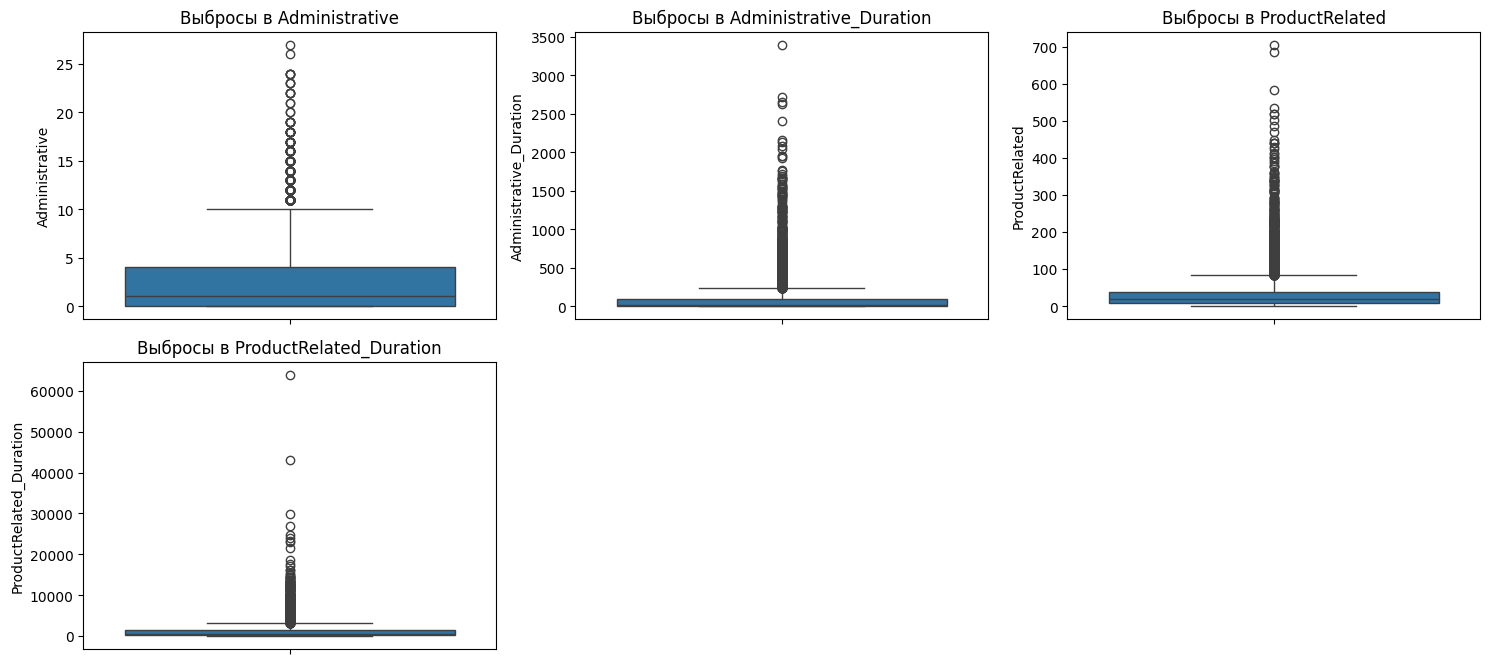

In [12]:
filter_cols = ['Administrative', 'Administrative_Duration', 'ProductRelated', 
                                                            'ProductRelated_Duration']

plt.figure(figsize=(15, 10))

for i, col in enumerate(filter_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Выбросы в {col}')

plt.tight_layout()
plt.show()

* Точки над/под «усами»: Это и есть те строки, которые пометим как True в potential_outliers.
* Длина «усов»: Это и есть threshold=1.5.
* Плотность точек: Если **точек очень много и они идут сплошной линией**, то порог 1.5 слишком жесткий. Лучше поставим threshold = 3.0, чтобы не потерять ценные данные.

**Удаление выбросов**

In [22]:
potential_outliers = pd.DataFrame()

threshold = 3

for column in filter_cols:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    margin = threshold * IQR

    lower = Q1 - margin
    upper = Q3 + margin  

    potential_outliers[column] = ~df[column].between(lower, upper)

outliers = potential_outliers.any(axis=1)

print(f"До: {df.shape[0]} | После: {(~outliers).sum()} | Удалено: {outliers.sum()}")
    

df = df[~outliers].reset_index(drop=True)

До: 12221 | После: 11162 | Удалено: 1059


**Плотность распределения данных**

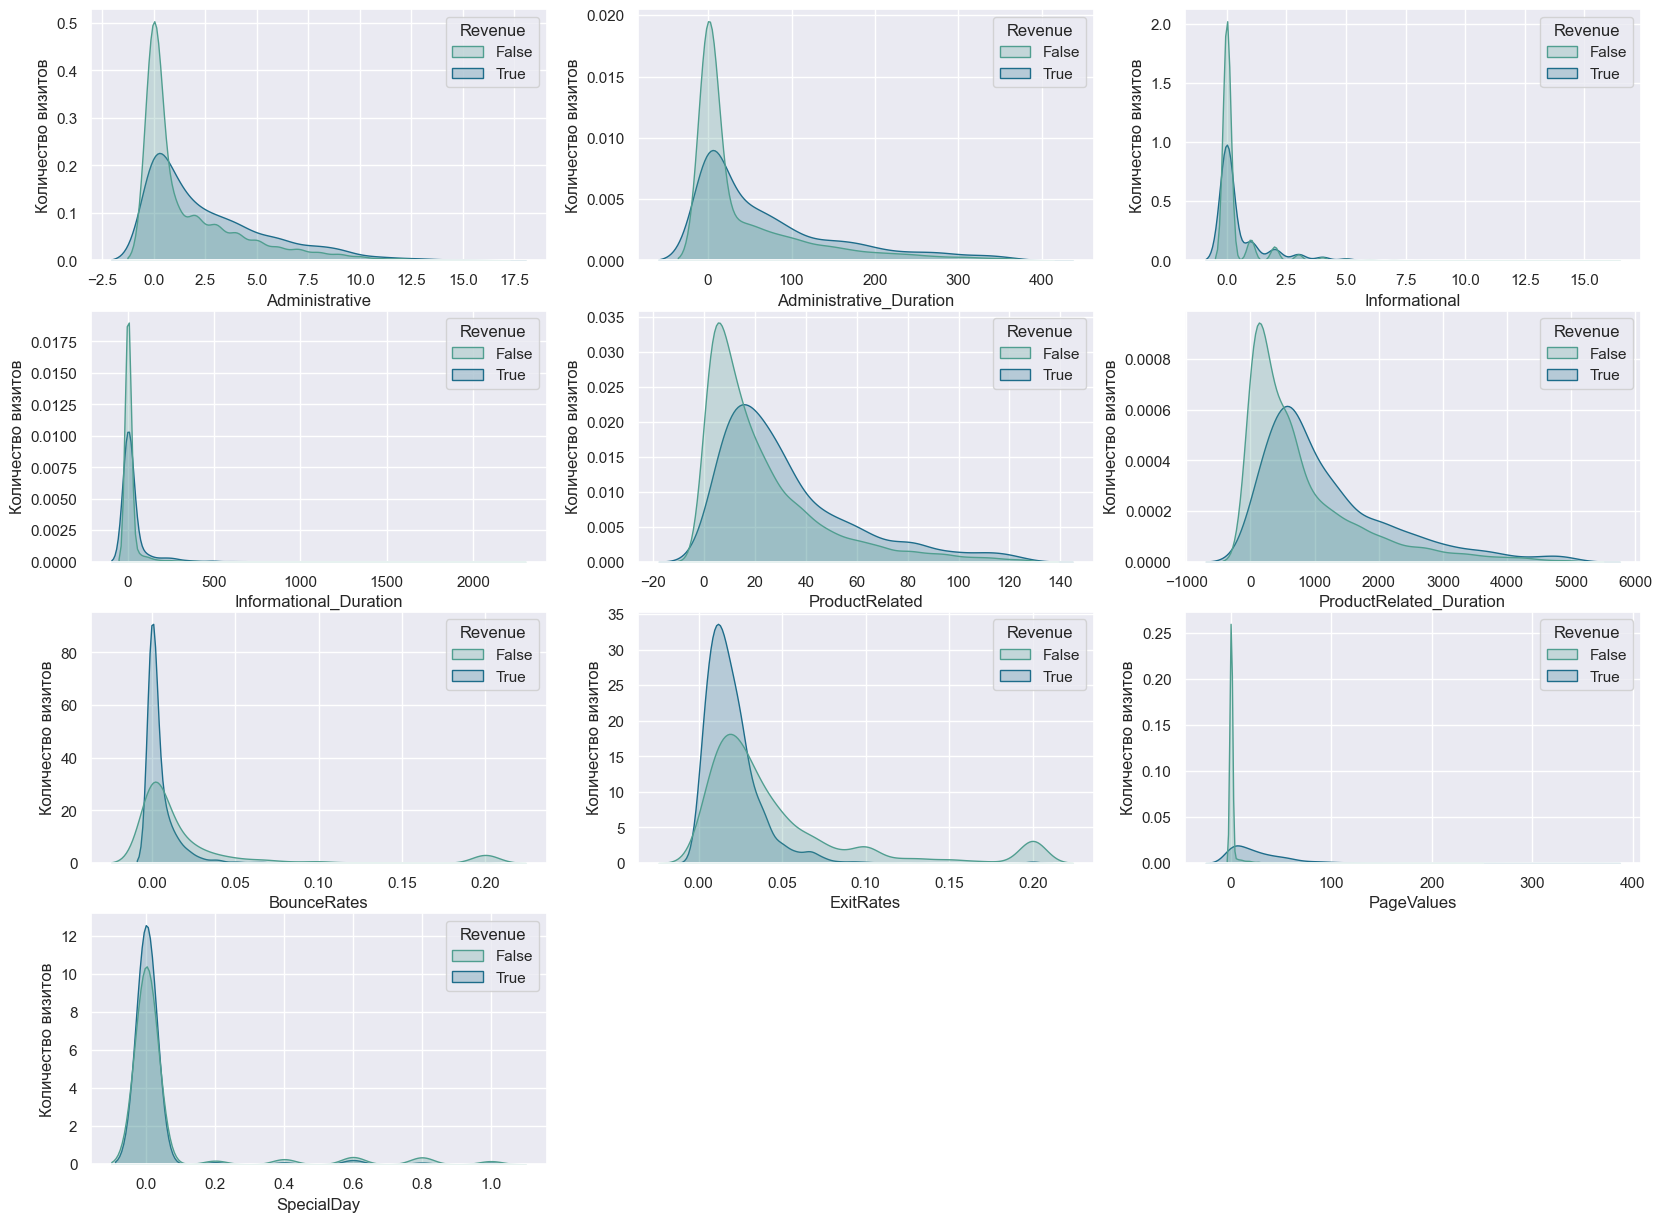

In [53]:
num_columns = ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 
'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

plt.figure(figsize=(20, 15))

for i, num_column in enumerate(num_columns, 1): 
   
    plt.subplot(4, 3, i)
    plt.ylabel('Количество визитов')
    sns.kdeplot(data=df, x=num_column, hue='Revenue', palette='crest', common_norm=False, fill=True)


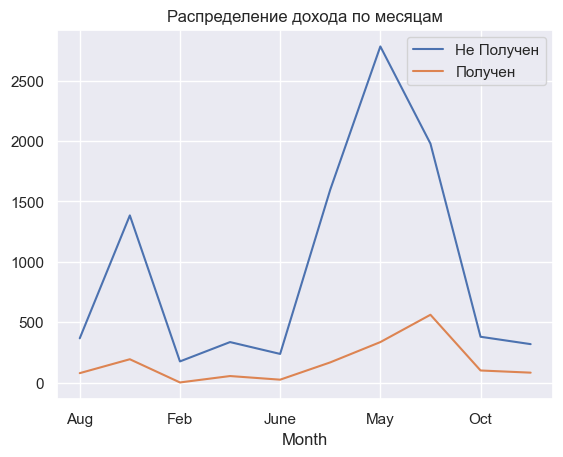

In [ ]:
dfg = df.groupby(['Month', 'Revenue']).size().unstack(fill_value=0)
dfg.columns = ['Не Получен', 'Получен']
dfg.plot(title="Распределение дохода по месяцам")

plt.show()

**Получение дохода**

,counts,percent
Revenue,,
False,9557,85.6%
True,1605,14.4%


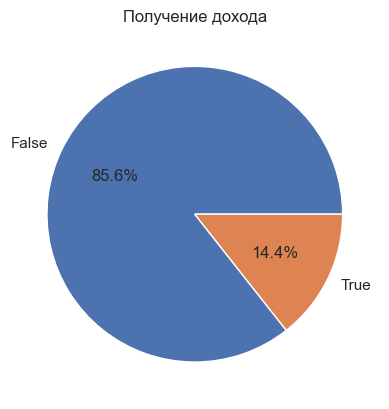

In [54]:
series_revenue = df["Revenue"].value_counts()
series_revenue_pct = series_revenue/df["Revenue"].value_counts().sum()
series_format = "{:.1%}".format

gr = pd.DataFrame({"counts": series_revenue, "percent": series_revenue_pct.apply(series_format)})

display(gr)

plt.pie(gr['counts'], labels=gr['counts'].index.to_list(), autopct='%1.1f%%')
plt.title("Получение дохода")
plt.show()

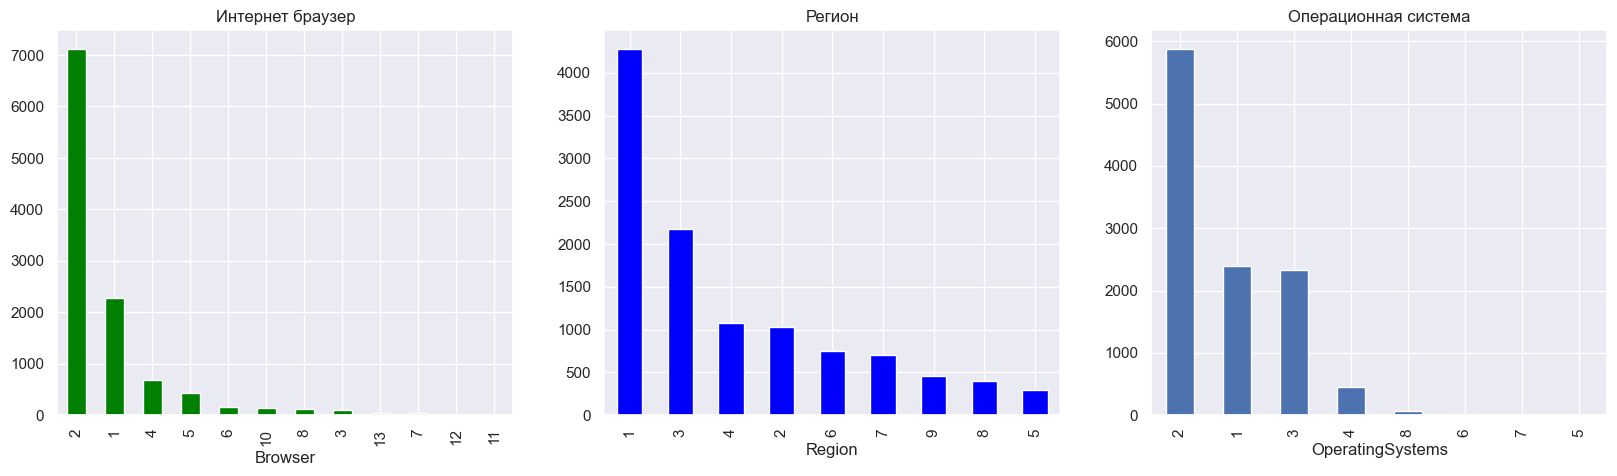

In [27]:
sns.set_theme(style="darkgrid")

plt.figure(figsize=(20, 5))
plt.axis('off')

plt.figure(1)
plt.subplot(131)
df['Browser'].value_counts().plot.bar(title="Интернет браузер", color='green')
plt.subplot(132)
df['Region'].value_counts().plot.bar(title="Регион", color='blue')
plt.subplot(133)
df['OperatingSystems'].value_counts().plot.bar(title="Операционная система")
plt.show()

In [28]:
series_revenue = df["Region"].value_counts()

series_revenue_pct = series_revenue/df["Region"].value_counts().sum()

series_format_percent = "{:.1%}".format
series_format_count = "{:,d}".format

display(pd.DataFrame({"counts": series_revenue.apply(series_format_count), \
                      "percent": series_revenue_pct.apply(series_format_percent)}))

,counts,percent
Region,,
1,"4,283",38.4%
3,"2,172",19.5%
4,"1,072",9.6%
2,"1,034",9.3%
6,751,6.7%
7,698,6.3%
9,464,4.2%
8,397,3.6%
5,291,2.6%


**Взаимосвязь между двумя переменными и распределение каждой из них по отдельности**

* Центральный график: Показывает совместное распределение (bivariate). По умолчанию это диаграмма рассеяния (scatter plot), которая наглядно демонстрирует корреляцию и паттерны между осями X и Y.
* Верхний график: Показывает одномерное распределение (univariate) переменной по оси X (обычно гистограмма или KDE).
* Правый график: Показывает одномерное распределение переменной по оси Y

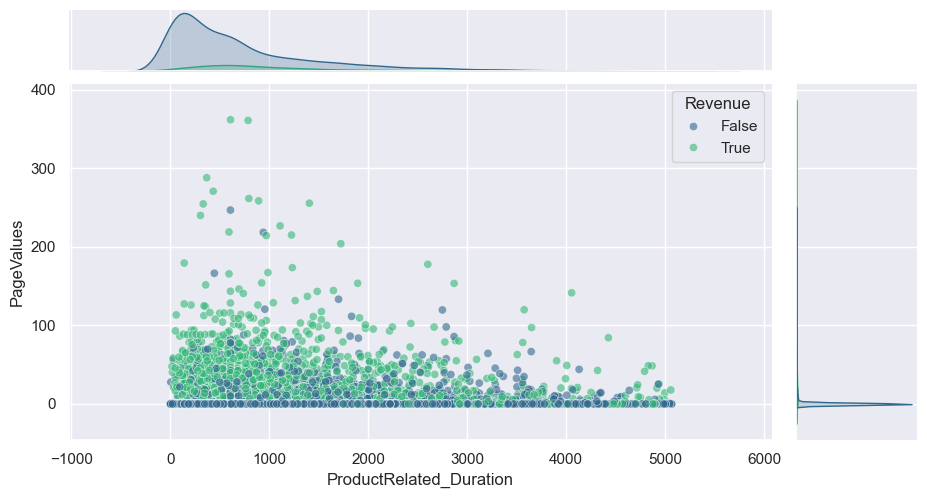

In [ ]:
g.figure.set_size_inches(10, 5)
g = sns.jointplot(data=df, x='ProductRelated_Duration', y='PageValues', hue='Revenue', palette='viridis', alpha=0.6)
plt.show()

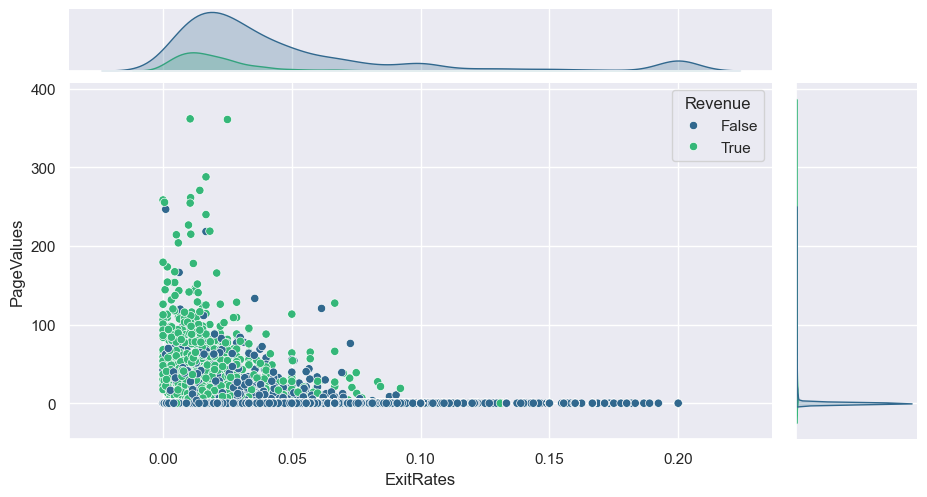

In [ ]:
g.figure.set_size_inches(10, 5)
g = sns.jointplot(data=df, x='ExitRates', y='PageValues', hue='Revenue', palette='viridis', alpha=0.6)
plt.show()

* Там, где цвет станет очень густым, и находится «портрет» типичного покупателя.


**Корреляция**

In [30]:
correlations = df.corr(numeric_only=True)['Revenue'].sort_values(ascending=False)
print(correlations)

Revenue                    1.000000
PageValues                 0.519220
ProductRelated_Duration    0.150459
ProductRelated             0.142266
Administrative             0.117711
Administrative_Duration    0.111856
Informational              0.082828
Informational_Duration     0.058093
Weekend                    0.034500
Browser                    0.027818
Region                     0.000148
TrafficType               -0.001778
OperatingSystems          -0.010604
SpecialDay                -0.076361
BounceRates               -0.144481
ExitRates                 -0.200357
Name: Revenue, dtype: float64


* Близко к 1.0 (например, 0.6 – 0.8): Очень сильная связь. Если растет этот показатель (например, PageValues), шанс покупки резко возрастает.
* Около 0 (например, 0.02 или -0.01): Связи нет. Этот параметр (например, TrafficType) почти не влияет на то, купит человек или нет.
* Отрицательное значение (например, -0.2): Обратная связь. Чем выше показатель (например, ExitRates — процент уходов со страницы), тем меньше вероятность покупки.

*Самые важные признаки для покупки*

In [36]:
importance = df.corr(numeric_only=True)['Revenue'].abs().sort_values(ascending=False)
print(importance.head(5))

Revenue                    1.000000
PageValues                 0.519220
ExitRates                  0.200357
ProductRelated_Duration    0.150459
BounceRates                0.144481
Name: Revenue, dtype: float64


*Матрица корреляции признаков*

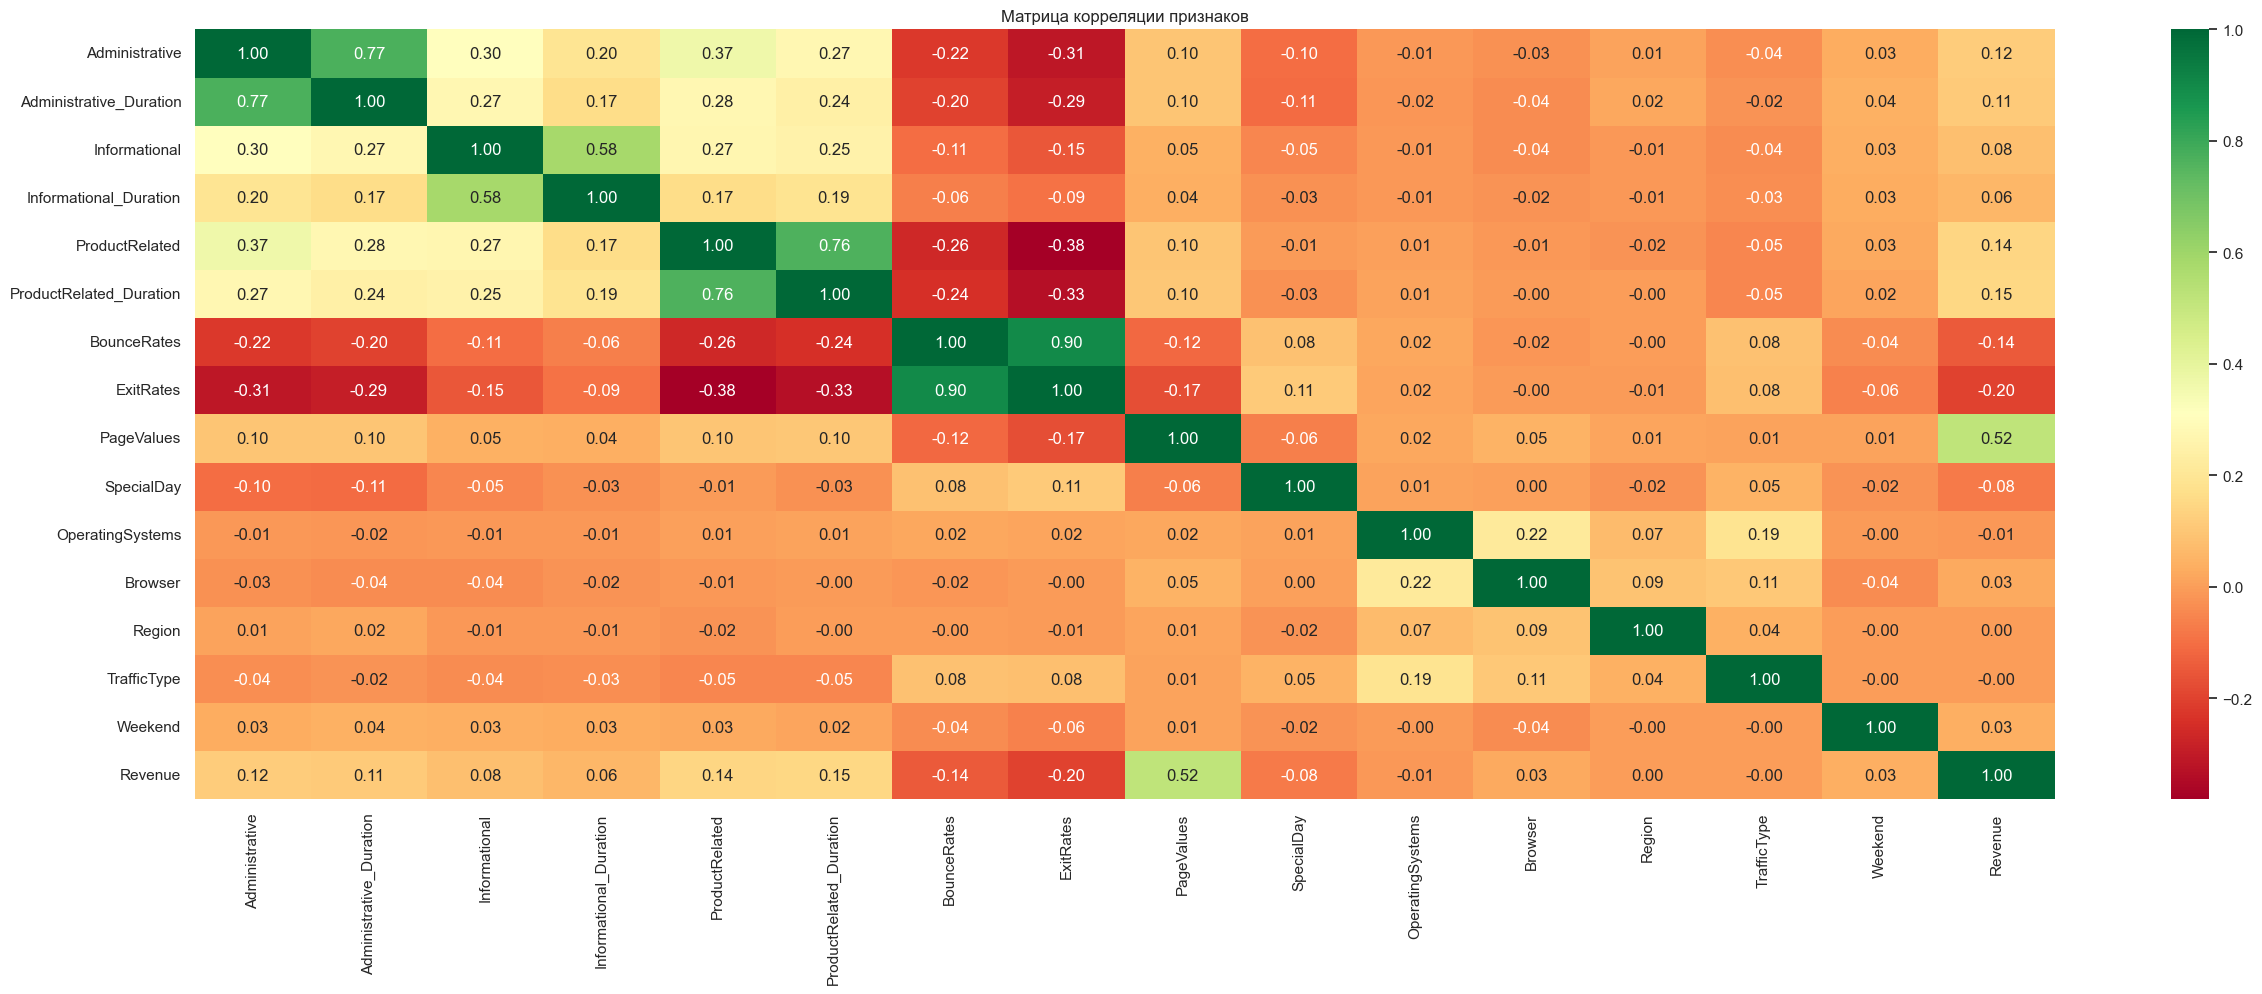

In [32]:
plt.figure(figsize=(30, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Матрица корреляции признаков')
plt.show()

*Дополнительное исследования*

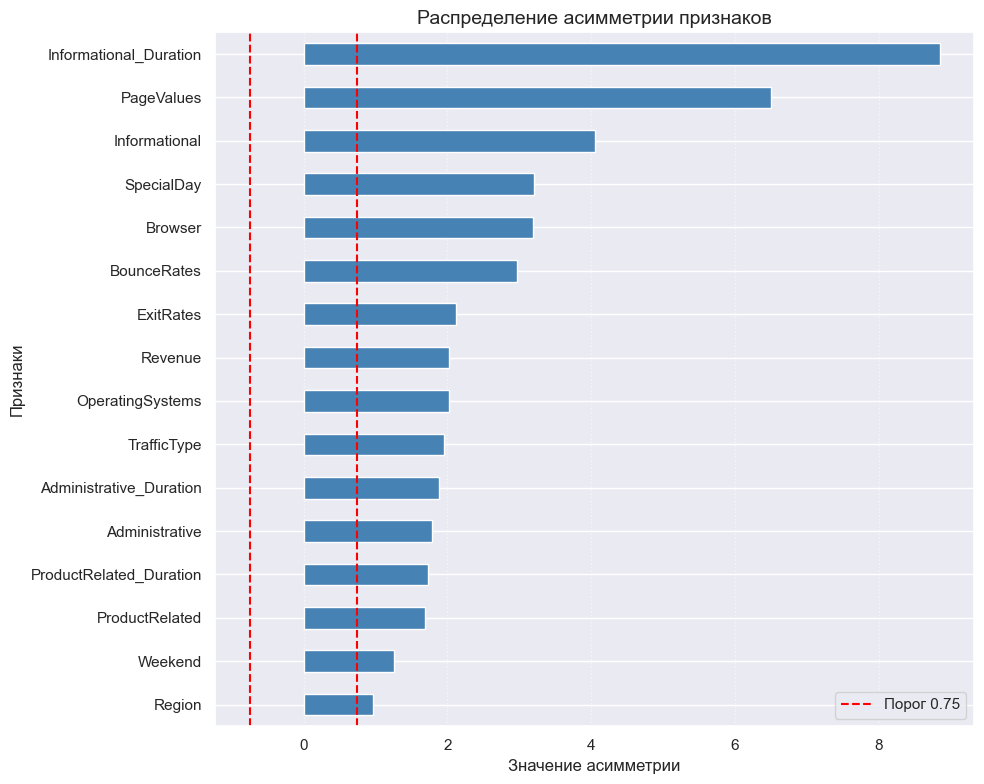

In [37]:
skewed_feats = df.skew(numeric_only=True).sort_values(ascending=True)
skewed_feats_result = skewed_feats[lambda x: x.abs() > 0.75]

plt.figure(figsize=(10, 8))
skewed_feats_result.plot(kind='barh', color='steelblue', zorder=2)

plt.axvline(x=0.75, color='red', linestyle='--', linewidth=1.5, label='Порог 0.75')
plt.axvline(x=-0.75, color='red', linestyle='--', linewidth=1.5)

plt.title('Распределение асимметрии признаков', fontsize=14)
plt.xlabel('Значение асимметрии')
plt.ylabel('Признаки')
plt.legend()
plt.grid(axis='x', linestyle=':', alpha=0.6, zorder=1)

plt.tight_layout()
plt.show()

*Вывод: Распределение асимметрии признаков правосторонее по всем показателем > 0.75*
* Skew ≈ 0 — симметричное распределение.
* Skew > 0 — распределение положительно (правостороннее), «хвост» данных уходит вправо, в сторону больших значений.
* Skew < 0 — распределение отрицательно (левостороннее), «хвост» данных уходит влево, в сторону маленьких значений.

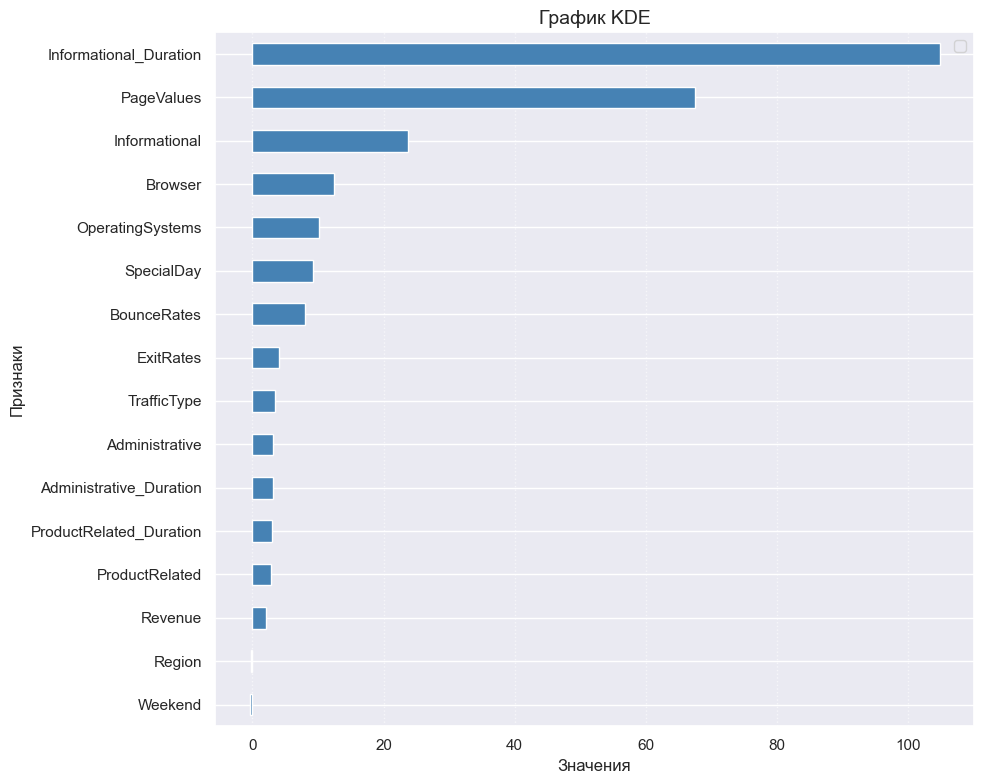

In [212]:
plt.figure(figsize=(10, 8))
df.kurtosis(numeric_only=True).sort_values(ascending=True).plot(kind='barh', color='steelblue', zorder=2)
plt.title('График KDE', fontsize=14)
plt.xlabel('Значения')
plt.ylabel('Признаки')
plt.legend()
plt.grid(axis='x', linestyle=':', alpha=0.6, zorder=1)

plt.tight_layout()
plt.show()

*Вывод: Насколько сильно распределение влияет на экстремальные значения (выбросы)*
* Если куртозис больше 0, распределение leptokurtic — хвосты толще, чем у нормального, что указывает на кластер выбросов.
* Если куртозис меньше 0, распределение platykurtic — хвосты тоньше, чем у нормального, что означает отрицательный избыток выбросов.
* Если куртозис равен 0, распределение mesokurtic — хвосты такие же, как у нормального распределения.

<h5>ML Модель<h5>

**Дерево решений (Decision Tree)**

*Дерево решений (Decision Tree) — оно отлично подходит, потому что наглядно показывает, какие признаки важнее всего*

In [40]:
X = df[['PageValues', 'ExitRates', 'ProductRelated_Duration']]
y = df['Revenue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(max_depth=3)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print(f"Точность модели: {accuracy_score(y_test, predictions):.2%}")


Точность модели: 90.55%


**Логика принятия решения моделью**

In [ ]:
tree_rules = export_text(model, feature_names=['PageValues', 'ExitRates', 'ProductRelated_Duration'])

print(tree_rules)

Логика принятия решения моделью:
|--- PageValues <= 6.09
|   |--- PageValues <= 0.05
|   |   |--- ProductRelated_Duration <= 2404.45
|   |   |   |--- class: False
|   |   |--- ProductRelated_Duration >  2404.45
|   |   |   |--- class: False
|   |--- PageValues >  0.05
|   |   |--- ProductRelated_Duration <= 1320.34
|   |   |   |--- class: False
|   |   |--- ProductRelated_Duration >  1320.34
|   |   |   |--- class: False
|--- PageValues >  6.09
|   |--- PageValues <= 29.77
|   |   |--- ProductRelated_Duration <= 1051.53
|   |   |   |--- class: True
|   |   |--- ProductRelated_Duration >  1051.53
|   |   |   |--- class: False
|   |--- PageValues >  29.77
|   |   |--- ExitRates <= 0.03
|   |   |   |--- class: True
|   |   |--- ExitRates >  0.03
|   |   |   |--- class: True



**Графическая схема принятия решения моделью**

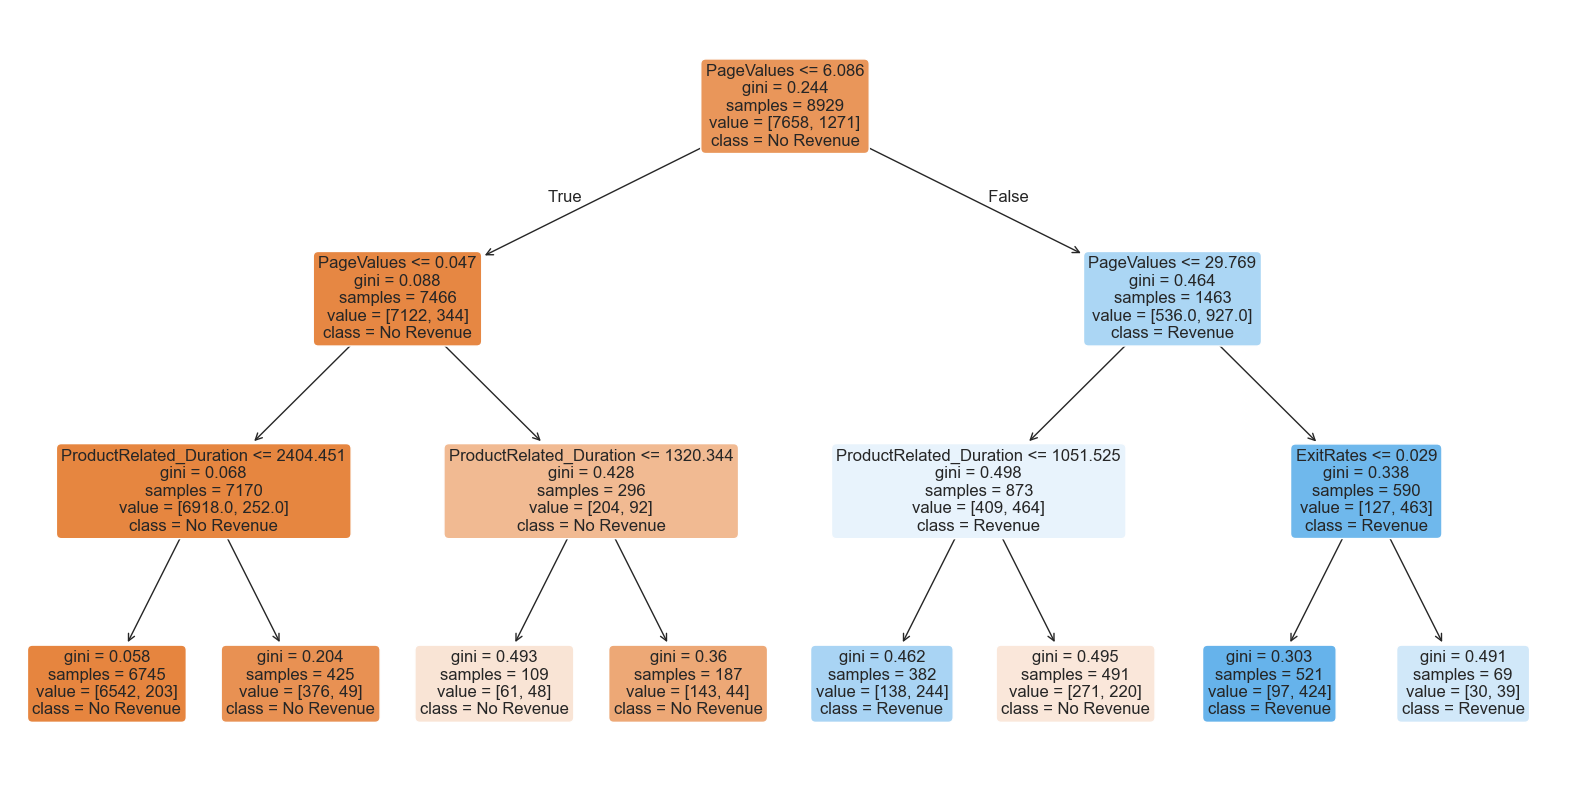

In [41]:
plt.figure(figsize=(20, 10))
plot_tree(model, 
          feature_names=['PageValues', 'ExitRates', 'ProductRelated_Duration'], 
          class_names=['No Revenue', 'Revenue'], 
          filled=True, 
          rounded=True, 
          fontsize=12)

plt.show()

**Вывод:**
* Цвет: Чем насыщеннее синий цвет в блоке, тем выше вероятность покупки в этой группе пользователей. Чем гуще оранжевый — тем меньше шансов.
* samples: Показывает, сколько пользователей из твоей выборки попало в это конкретное правило (ветку).
* Первая строка в блоке: Это условие (например, PageValues <= 0.96). Если оно выполняется, мы идем влево, если нет — вправо.

**CatBoost — это библиотека от Яндекса, которая сейчас считается «золотым стандартом» для табличных данных.**

In [42]:
X = df[['PageValues', 'ExitRates', 'ProductRelated_Duration', 'Month', 'VisitorType']]
y = df['Revenue']

cat_features = ['Month', 'VisitorType']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_cb = CatBoostClassifier(iterations=500, learning_rate=0.1, depth=6, verbose=100)
model_cb.fit(X_train, y_train, cat_features=cat_features)

predictions = model_cb.predict(X_test)
print(classification_report(y_test, predictions))


0:	learn: 0.5761614	total: 286ms	remaining: 2m 22s
100:	learn: 0.1939128	total: 7.89s	remaining: 31.2s
200:	learn: 0.1713588	total: 15.5s	remaining: 23s
300:	learn: 0.1542416	total: 22.9s	remaining: 15.1s
400:	learn: 0.1416505	total: 30.4s	remaining: 7.49s
499:	learn: 0.1308201	total: 37.6s	remaining: 0us
              precision    recall  f1-score   support

       False       0.94      0.96      0.95      1899
        True       0.76      0.63      0.69       334

    accuracy                           0.91      2233
   macro avg       0.85      0.80      0.82      2233
weighted avg       0.91      0.91      0.91      2233



**Влияние признаков на покупку**

                Feature Id Importances
0                    Month      44.21%
1               PageValues      20.72%
2                ExitRates      15.77%
3  ProductRelated_Duration      14.93%
4              VisitorType       4.37%


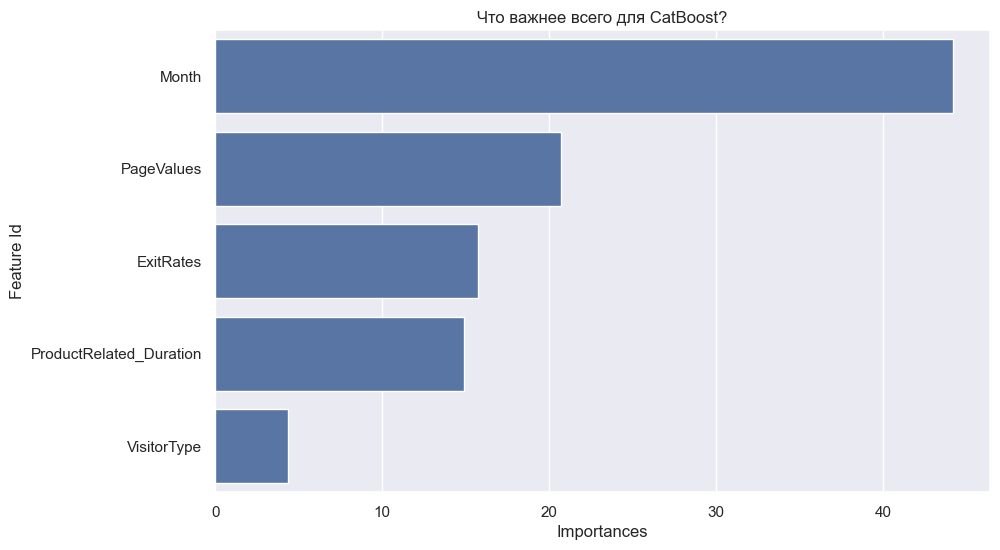

In [48]:
feature_importance = model_cb.get_feature_importance(prettified=True)

df_show = feature_importance.copy()
df_show['Importances'] = df_show['Importances'].apply(lambda x: f"{x:.2f}%")

print(df_show)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importances', y='Feature Id', data=feature_importance)
plt.title('Что важнее всего для CatBoost?')
plt.show()

**Вывод:**
По степени значимости Месяц, Ценность - являются наиболее выраженными показателями от которых зависит решения в большей степени.

**Заключение**
*В этом проекте я провел анализ данных о поведении посетителей сайта и выявил множество ключевых моментов.*